In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('LinearRegression-Prac-Dataset.csv')
df.head()

Saving LinearRegression-Prac-Dataset.csv to LinearRegression-Prac-Dataset.csv


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.shape

(414, 8)

In [ ]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [ ]:
df.dtypes

,0
No,int64
X1 transaction date,float64
X2 house age,float64
X3 distance to the nearest MRT station,float64
X4 number of convenience stores,int64
X5 latitude,float64
X6 longitude,float64
Y house price of unit area,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [ ]:
df.duplicated().any()

np.False_

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area


In [ ]:
House_data = df.drop_duplicates()

In [ ]:
House_data.shape

(414, 8)

In [ ]:
House_data.isnull().any()

,0
No,False
X1 transaction date,False
X2 house age,False
X3 distance to the nearest MRT station,False
X4 number of convenience stores,False
X5 latitude,False
X6 longitude,False
Y house price of unit area,False


In [ ]:
df = House_data.isnull().sum().reset_index()
df.columns = ['column', 'null_records']
df['% null_records'] = (df['null_records']/414)*100
df

,column,null_records,% null_records
0,No,0,0.0
1,X1 transaction date,0,0.0
2,X2 house age,0,0.0
3,X3 distance to the nearest MRT station,0,0.0
4,X4 number of convenience stores,0,0.0
5,X5 latitude,0,0.0
6,X6 longitude,0,0.0
7,Y house price of unit area,0,0.0


In [ ]:
House_data = House_data.dropna()

In [ ]:
House_data.shape

(414, 8)

In [ ]:
House_data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
House_data.tail()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5
413,414,2013.500,6.5,90.45606,9,24.97433,121.54310,63.9


**Numerical Data**

In [ ]:
numerical_coulmns = House_data.select_dtypes(include="number").columns.to_list()

In [ ]:
print(numerical_coulmns)

['No', 'X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']


**Categorical Data**

In [ ]:
Categorical_columns = House_data.select_dtypes(exclude="number").columns.to_list()

In [ ]:
print(Categorical_columns)

[]


In [ ]:
House_data.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
House_data1 = House_data.drop(columns=['X2 house age', 'X1 transaction date'], axis = 1)
House_data1

,No,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,84.87882,10,24.98298,121.54024,37.9
1,2,306.59470,9,24.98034,121.53951,42.2
2,3,561.98450,5,24.98746,121.54391,47.3
3,4,561.98450,5,24.98746,121.54391,54.8
4,5,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...
409,410,4082.01500,0,24.94155,121.50381,15.4
410,411,90.45606,9,24.97433,121.54310,50.0
411,412,390.96960,7,24.97923,121.53986,40.6
412,413,104.81010,5,24.96674,121.54067,52.5


In [ ]:
House_data1['Dataset']= 'Area_categorical'
House_data1

,No,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,Dataset
0,1,84.87882,10,24.98298,121.54024,37.9,Area_categorical
1,2,306.59470,9,24.98034,121.53951,42.2,Area_categorical
2,3,561.98450,5,24.98746,121.54391,47.3,Area_categorical
3,4,561.98450,5,24.98746,121.54391,54.8,Area_categorical
4,5,390.56840,5,24.97937,121.54245,43.1,Area_categorical
...,...,...,...,...,...,...,...
409,410,4082.01500,0,24.94155,121.50381,15.4,Area_categorical
410,411,90.45606,9,24.97433,121.54310,50.0,Area_categorical
411,412,390.96960,7,24.97923,121.53986,40.6,Area_categorical
412,413,104.81010,5,24.96674,121.54067,52.5,Area_categorical


In [ ]:
Categorical_columns = House_data1.select_dtypes(exclude="object").columns
print(Categorical_columns)

Index(['No', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')


In [ ]:
House_data

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [ ]:
House_data.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
House_data['X2 house age'].value_counts()

,count
X2 house age,
0.0,17
13.6,7
13.3,6
16.2,6
13.2,6
...,...
26.8,1
7.6,1
1.9,1


In [ ]:
for col in Categorical_columns:
  print(House_data[col].value_counts())
  print("")
  print("-----")

No
414    1
1      1
2      1
3      1
4      1
      ..
19     1
18     1
17     1
16     1
15     1
Name: count, Length: 414, dtype: int64

-----
X3 distance to the nearest MRT station
289.32480     13
90.45606      11
492.23130      9
104.81010      8
1360.13900     8
              ..
201.89390      1
2615.46500     1
1447.28600     1
3078.17600     1
4527.68700     1
Name: count, Length: 259, dtype: int64

-----
X4 number of convenience stores
5     67
0     67
3     46
1     46
6     37
7     31
4     31
8     30
9     25
2     24
10    10
Name: count, dtype: int64

-----
X5 latitude
24.97433    14
24.98203    13
24.96515     9
24.96674     9
24.96299     8
            ..
24.98353     1
24.95663     1
24.97293     1
24.96330     1
24.97923     1
Name: count, Length: 234, dtype: int64

-----
X6 longitude
121.54348    13
121.54310    11
121.53737     9
121.54391     8
121.54842     8
             ..
121.53874     1
121.49630     1
121.55063     1
121.53966     1
121.51243     1
Name

In [ ]:
House_data

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [ ]:
# Data  visulization

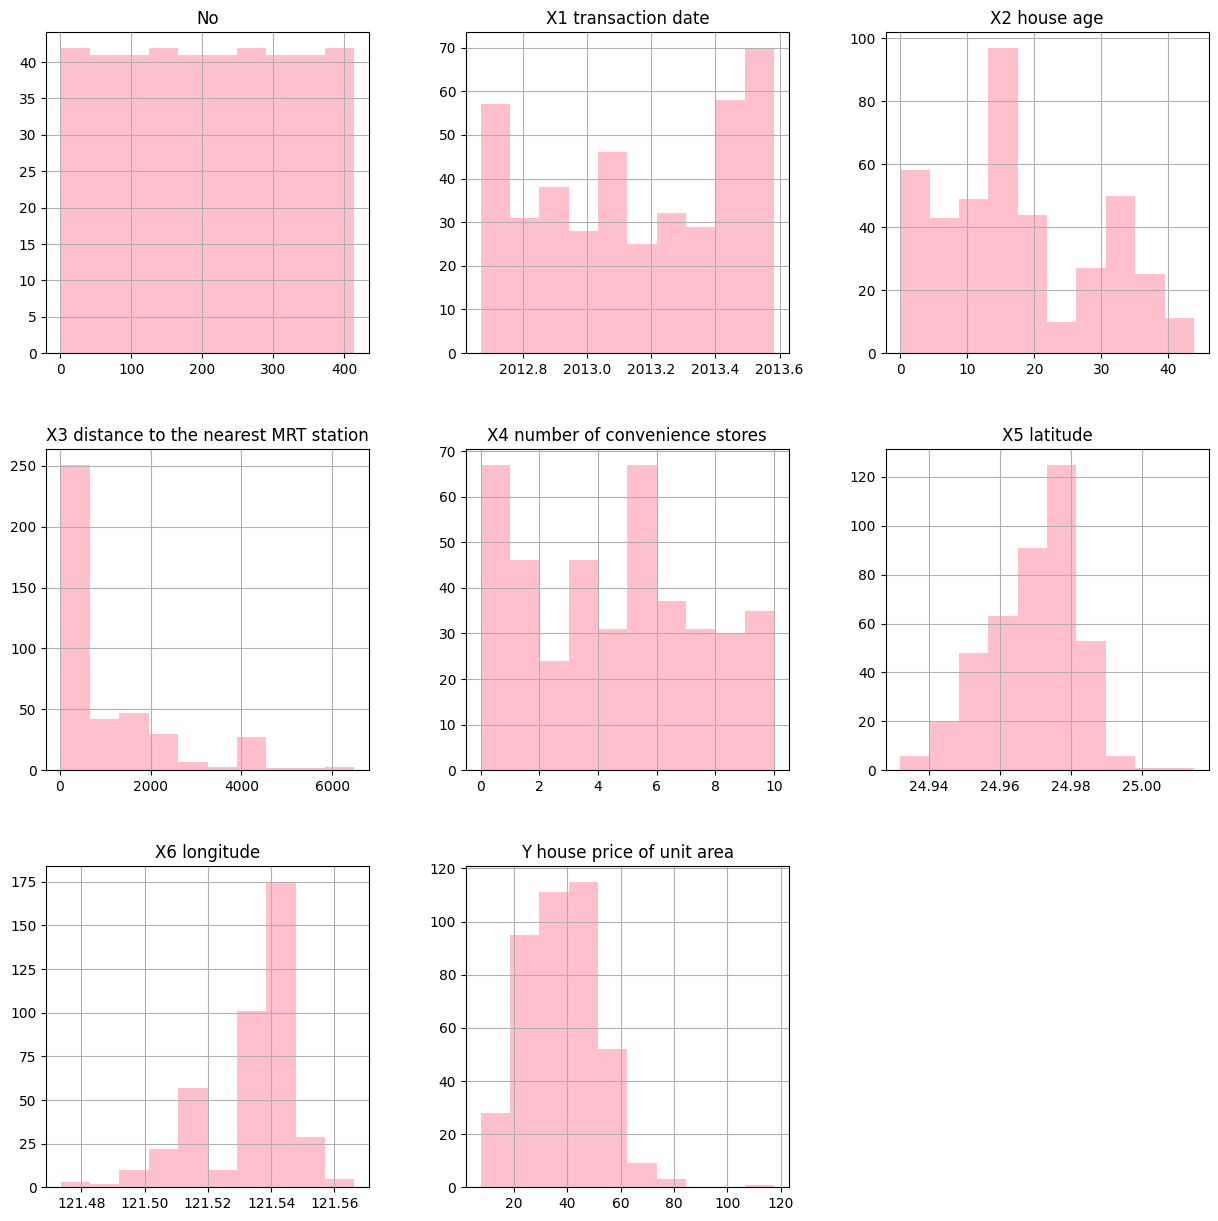

In [ ]:
# Histogram
House_data.hist(figsize=(15,15),color='Pink')
plt.show()

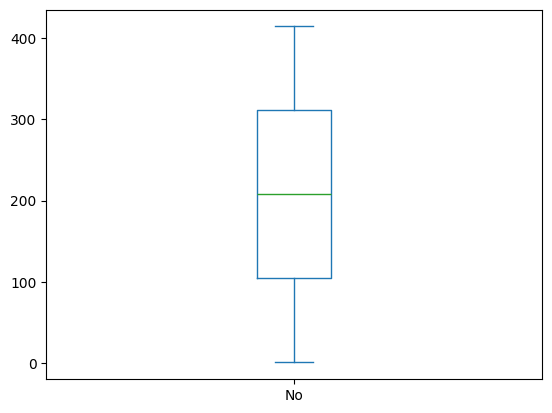

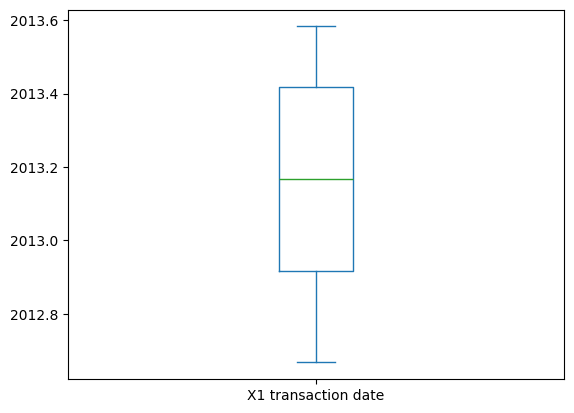

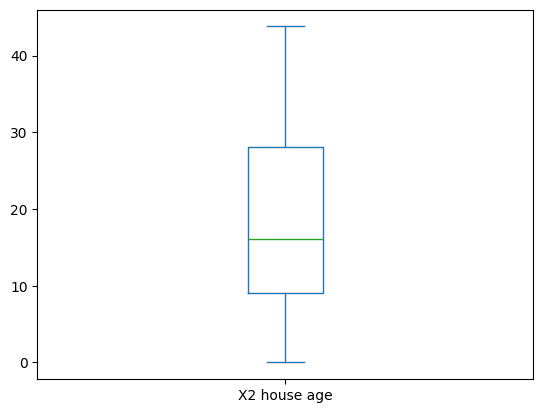

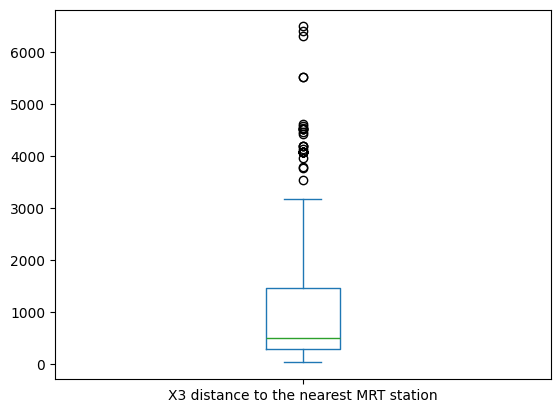

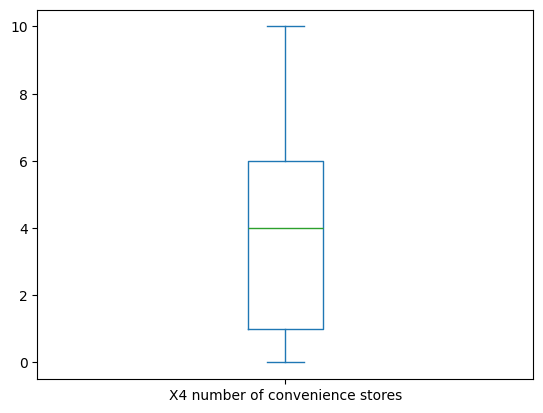

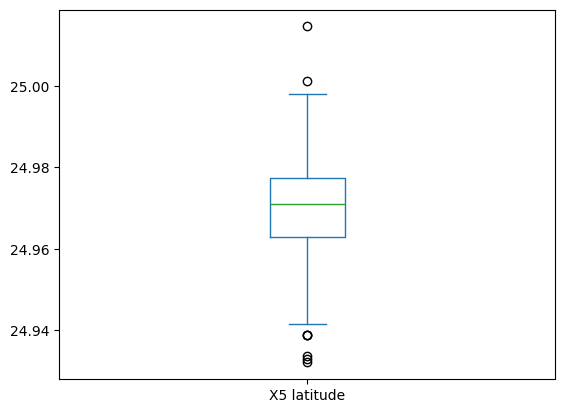

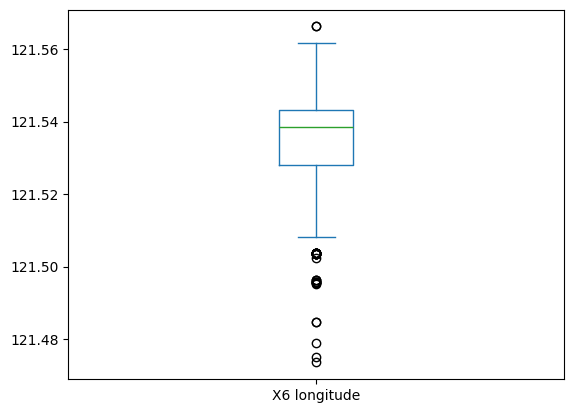

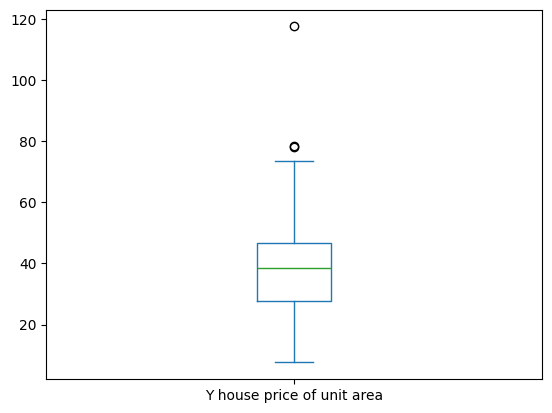

In [ ]:
# Box plot
for col in numerical_coulmns:
  House_data[col].plot(kind='box')
  plt.show()

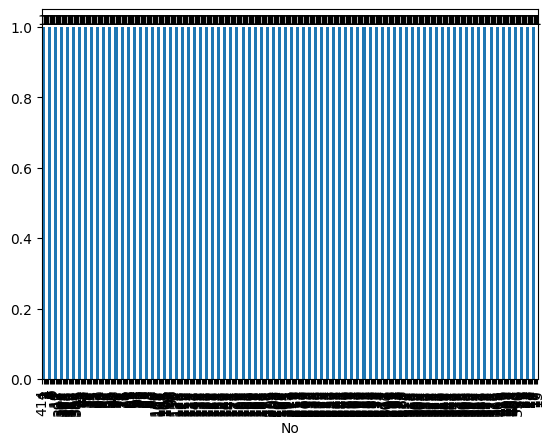

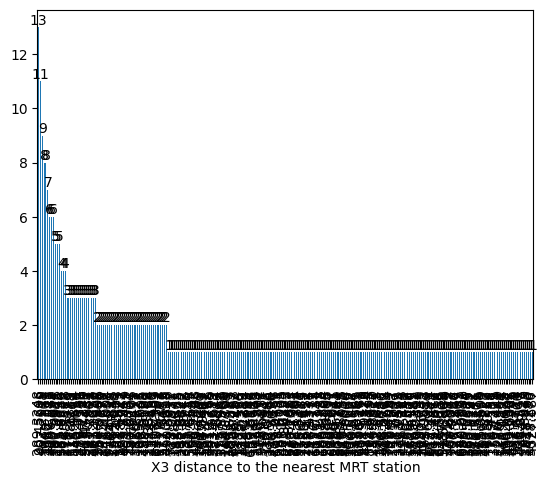

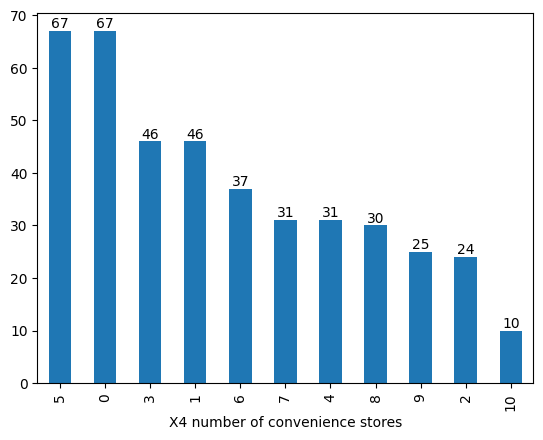

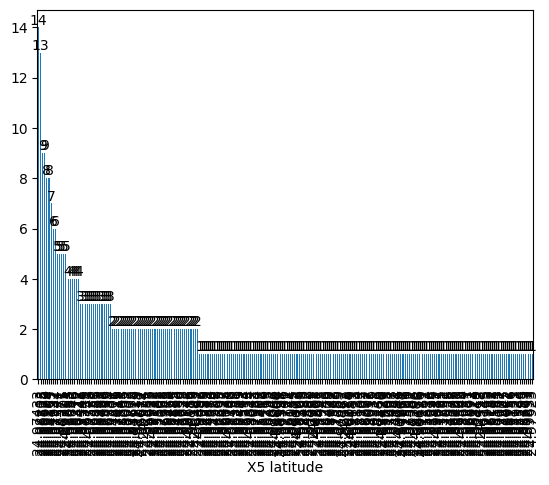

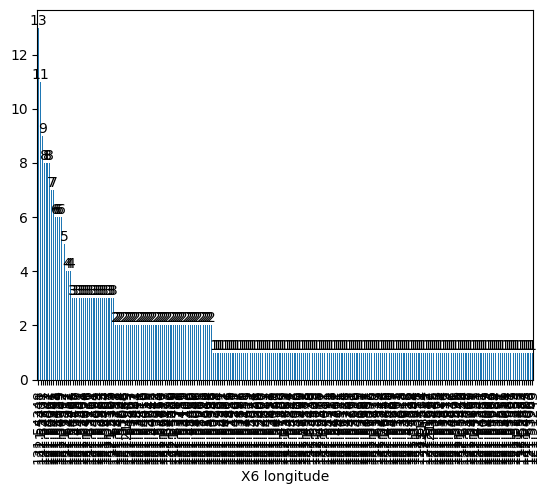

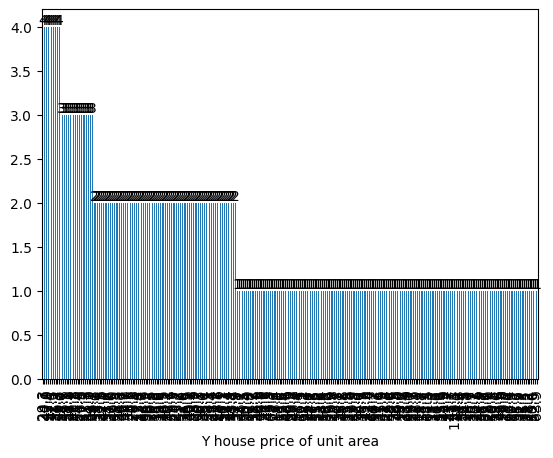

In [ ]:
# Bar Chart
for col in Categorical_columns:
  ax = House_data1[col].value_counts().plot(kind = 'bar')
  for i in ax.containers:
    ax.bar_label(i)
    plt.show()

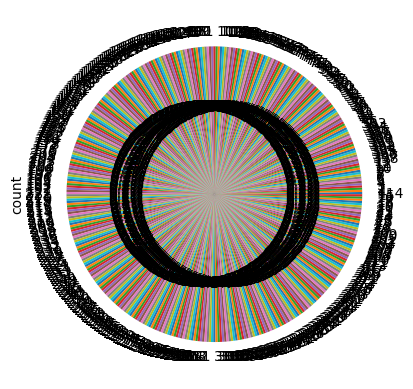

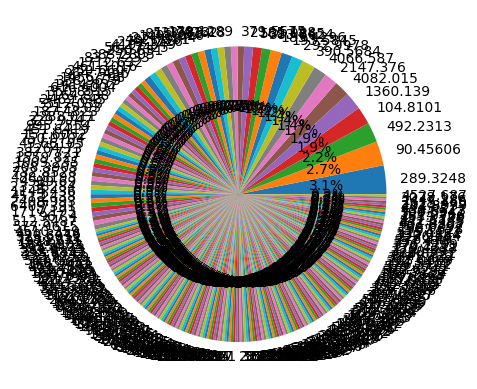

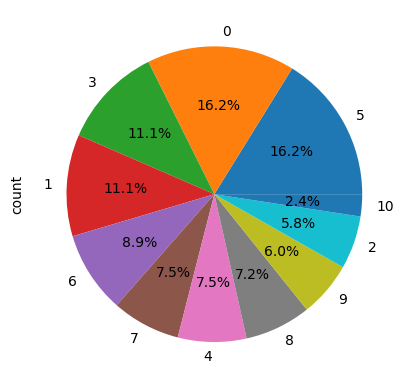

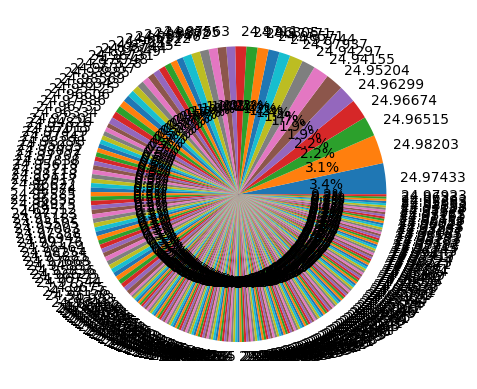

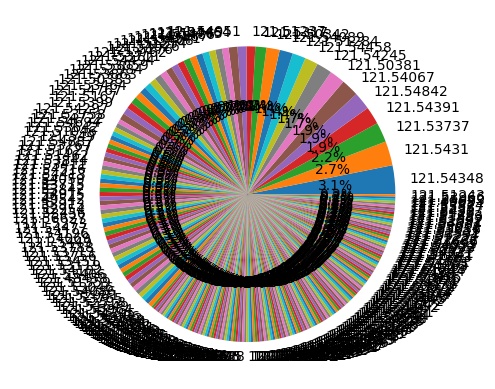

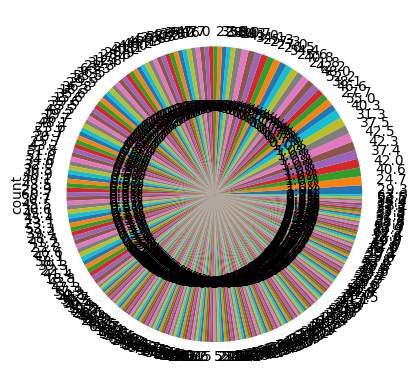

In [ ]:
# Pie Plot

for col in Categorical_columns:
  House_data1[col].value_counts().plot(kind = 'pie', autopct= '%1.1f%%')
  plt.show()

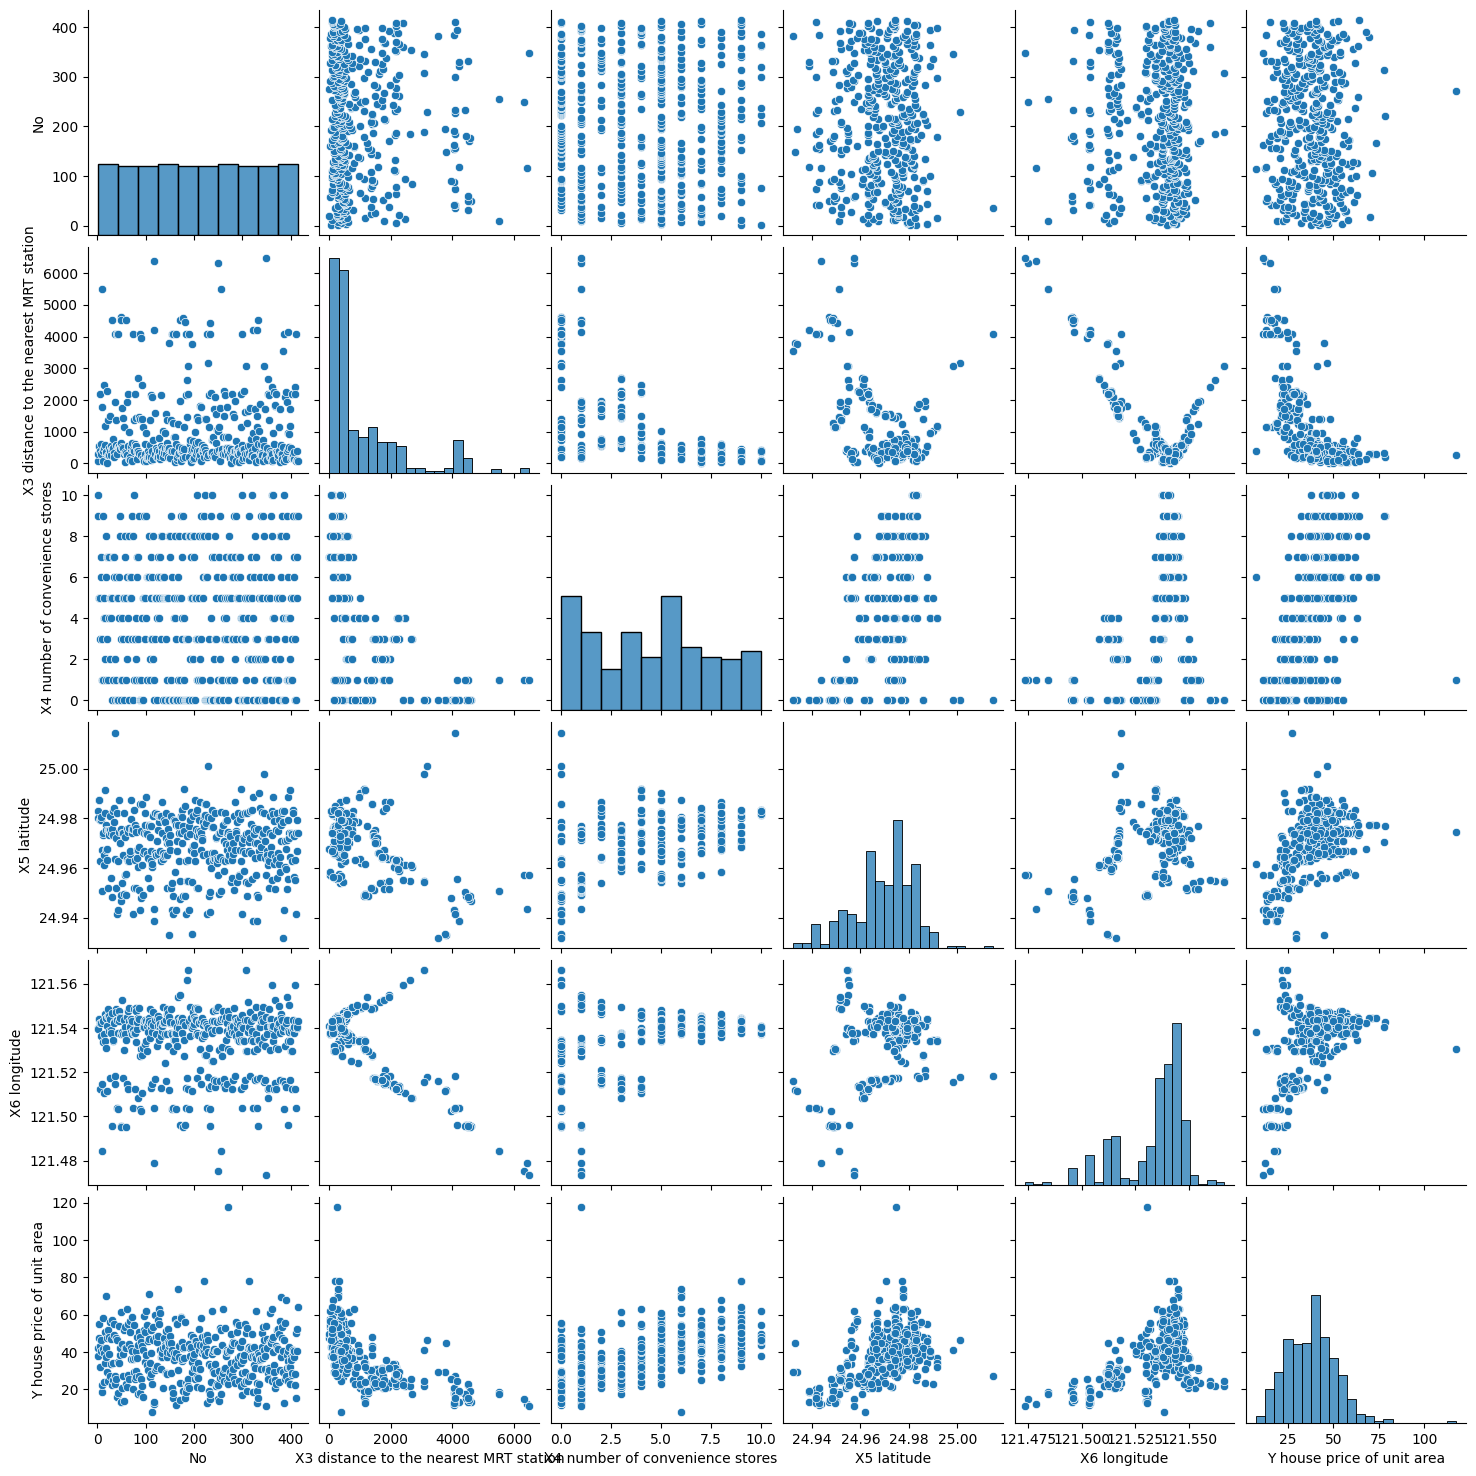

In [ ]:
# Pair plot
sns.pairplot(House_data1)
plt.show()

In [ ]:
# Correlation Matrix
corr_data = House_data[['No','X1 transaction date','X2 house age','X3 distance to the nearest MRT station']].corr()

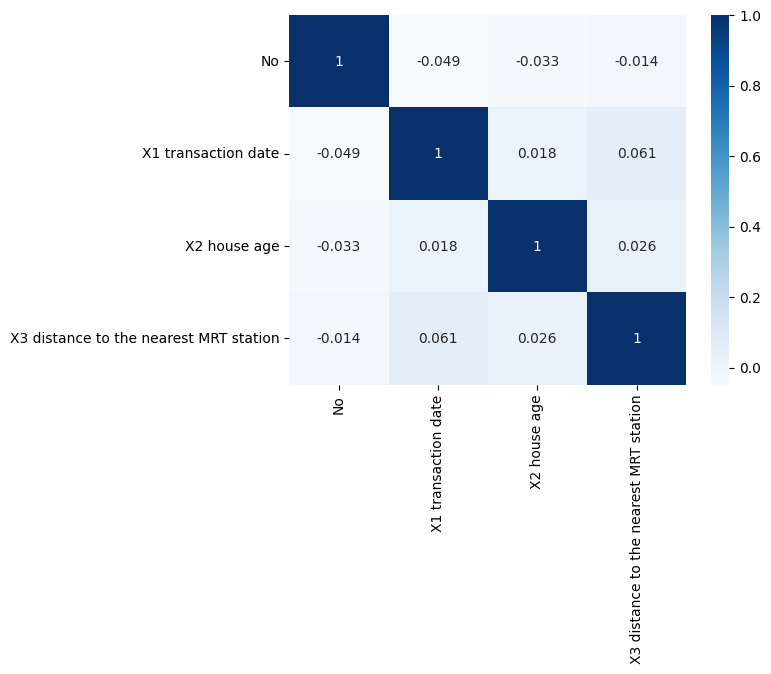

In [ ]:
sns.heatmap(corr_data, annot=True, cmap='Blues')
plt.show()

In [ ]:
House_data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
# Data Pre-Processing

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
House_data['No'] = le.fit_transform(House_data['No'])

In [ ]:
House_data['X1 transaction date'] = le.fit_transform(House_data['X1 transaction date'])

In [ ]:
House_data['X5 latitude'] = le.fit_transform(House_data['X5 latitude'])

In [ ]:
House_data

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,0,3,32.0,84.87882,10,210,121.54024,37.9
1,1,3,19.5,306.59470,9,188,121.53951,42.2
2,2,11,13.3,561.98450,5,225,121.54391,47.3
3,3,10,13.3,561.98450,5,225,121.54391,54.8
4,4,2,5.0,390.56840,5,183,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,409,4,13.7,4082.01500,0,4,121.50381,15.4
410,410,0,5.6,90.45606,9,142,121.54310,50.0
411,411,7,18.8,390.96960,7,180,121.53986,40.6
412,412,4,8.1,104.81010,5,87,121.54067,52.5


In [ ]:
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Objective:

The objective of this experiment is to implement
Linear Regression algorithm on a practice dataset
to predict the target variable
based on independent variables

Linear Regression finds the best fit line between
input and output variables to make predictions.

In [ ]:
# Define Featrue (x) and target (y)
x = House_data.drop("X1 transaction date",axis=1)
y = House_data["X1 transaction date"]

In [ ]:
x_train ,x_test, y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42)

print("\nTraning set Size:", x_train.shape)
print("\nTesting Set Size:", x_test.shape)



Traning set Size: (331, 7)

Testing Set Size: (83, 7)


In [ ]:
# step 5: Model Training

model = LinearRegression()
model.fit(x_train,y_train)

print("\nModel Trainig Completed successfully!")


Model Trainig Completed successfully!


In [ ]:
coeff_df = pd.DataFrame(model.coef_, x.columns,columns=["Coefficient"])
print("\nModel Coefficients:")
print(coeff_df)
print("Intercept:",model.intercept_)


Model Coefficients:
                                        Coefficient
No                                        -0.000073
X2 house age                               0.017302
X3 distance to the nearest MRT station     0.000708
X4 number of convenience stores           -0.034849
X5 latitude                               -0.000657
X6 longitude                              13.372269
Y house price of unit area                 0.061355
Intercept: -1622.3528551127968


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
# Step 8: Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R2 Score: {r2:.3f}")


Model Performance:
Mean Absolute Error (MAE): 2.91
Mean Squared Error (MSE): 11.32
R2 Score: -0.059


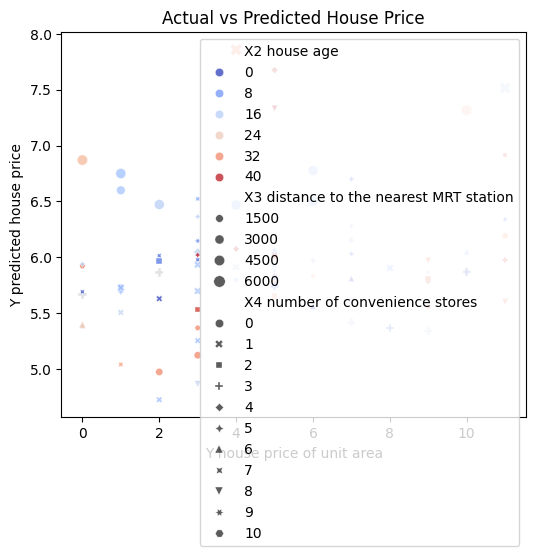

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(6,5))

sns.scatterplot(x=y_test, y=y_pred,
                hue=x_test['X2 house age'],
                size=x_test['X3 distance to the nearest MRT station'],
                style=x_test['X4 number of convenience stores'],
                palette='coolwarm',   # coolwarm : low value, high value , data range
                alpha=0.8)

plt.xlabel("Y house price of unit area")
plt.ylabel("Y predicted house price")
plt.title("Actual vs Predicted House Price")
plt.show()
plt.savefig("Scatter-plot.png")

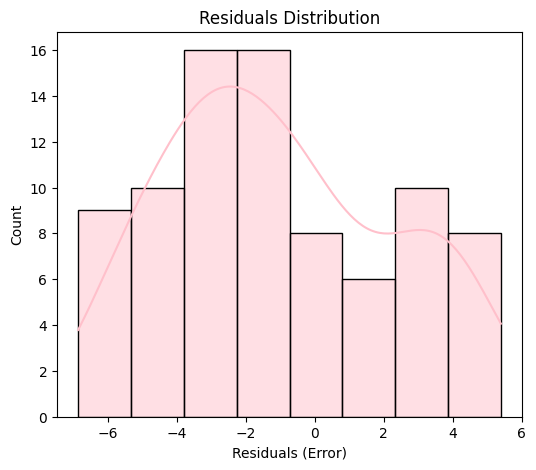

<Figure size 640x480 with 0 Axes>

In [ ]:
# Residual Plot
plt.figure(figsize=(6,5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='Pink')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (Error)")

plt.show()
plt.savefig("Histogram.png")

**Conclusion:**

In this experiment, Linear Regression was applied
on a practice dataset to predict

The dataset was preprocessed by handling
missing values using SimpleImputer.

The model was trained on 80% data and
tested on 20% data.

R2 Score: _-0.059

MSE: _11.32

MAE: _2.91

The model successfully learned the linear
relationship between experience, age and salary.